# VIPER Model - External Validation (ENIGMA BRCA Exchange)

**Pipeline stage:** 5 of 5  
**Inputs:** `variants_output.tsv` (BRCA Exchange), `rf_model_tuned.pkl`, `feature_cols.pkl`,  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`enigma_vep_annotated.vcf`, `enigma_cadd_output.tsv.gz`  
**Outputs:** `enigma_validation_results.tsv`, `enigma_validation_stats.json`,  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`vus_enigma_concordance.tsv`, figures `val_01_` → `val_06_`  

---

## Contents
1. [Imports & Configuration](#1-imports--configuration)
2. [Load & Parse ENIGMA Variants](#2-load--parse-enigma-variants)
   - 2.1 Load BRCA Exchange dataset
   - 2.2 Parse genomic coordinates
   - 2.3 Export VCF for annotation
3. [Parse VEP + CADD Annotations](#3-parse-vep--cadd-annotations)
   - 3.1 Parse VEP output
   - 3.2 Merge CADD scores
4. [Feature Engineering](#4-feature-engineering)
5. [ML Prediction & Concordance](#5-ml-prediction--concordance)
6. [VUS Discordance Analysis](#6-vus-discordance-analysis)
7. [Visualisation Suite](#7-visualisation-suite)
   - Plot 1: Concordance heatmap
   - Plot 2: ROC curve
   - Plot 3: Probability distribution
   - Plot 4: Concordance bars by ENIGMA class
   - Plot 5: Performance metrics summary
   - Plot 6: VUS reclassification concordance
8. [Export Results](#8-export-results)


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import gzip
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, confusion_matrix
)

COLORS = {'Pathogenic': '#D7191C', 'Benign': '#2C7BB6', 'VUS': '#FDAE61'}

PATHO_THRESHOLD  = 0.80
BENIGN_THRESHOLD = 0.20

# Load model and feature list
with open('rf_model_tuned.pkl', 'rb') as f:
    rf_best = pickle.load(f)

with open('feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print(f'Model: {rf_best}')
print(f'Feature cols: {feature_cols}')

Model: RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                       random_state=42)
Feature cols: ['PHRED', 'MAX_AF', 'PolyPhen_score', 'IMPACT_encoded', 'VARIANT_CLASS_encoded', 'BIOTYPE_encoded', 'SIFT_cat_encoded', 'PolyPhen_cat_encoded', 'Consequence_grouped_encoded']


## 2. Load & Parse ENIGMA Variants

### 2.1 Load BRCA Exchange Dataset

In [3]:
brca = pd.read_csv('/home/nayeema/Sysgen/VUS/BRCA/output/variants_output.tsv', sep='\t', low_memory=False)
print(f'Shape: {brca.shape}')
print(f'\nColumns: {brca.columns.tolist()}')

Shape: (77279, 309)

Columns: ['gene_symbol', 'genomic_vcf38', 'pos', 'ref', 'alt', 'genomic_hgvs_38', 'cdna', 'protein', 'source', 'clinical_significance_enigma', 'details on how the provisional acmg popfreq evidence code was determined   "this variant is absent from gnomad v2.1 (exomes only, non-cancer subset, read depth ≥25) and gnomad v3.1 (non-cancer subset, read depth ≥25) (pm2_supporting met)"', ' #skip', 'genomic  hgvs string specifying the variant', 'allele_count_exome_afr_gnomadv2', 'allele_count_exome_amr_gnomadv2', 'allele_count_exome_asj_gnomadv2', 'allele_count_exome_eas_gnomadv2', 'allele_count_exome_eas_jpn_gnomadv2', 'allele_count_exome_eas_kor_gnomadv2', 'allele_count_exome_eas_oea_gnomadv2', 'allele_count_exome_fin_gnomadv2', 'allele_count_exome_gnomadv2', 'allele_count_exome_nfe_bgr_gnomadv2', 'allele_count_exome_nfe_est_gnomadv2', 'allele_count_exome_nfe_gnomadv2', 'allele_count_exome_nfe_nwe_gnomadv2', 'allele_count_exome_nfe_onf_gnomadv2', 'allele_count_exome_nfe

### 2.2 Parse Genomic Coordinates

In [4]:
# Retain ENIGMA-classified (Pathogenic/Benign) variants for validation
enigma_classified = brca[
    brca['clinical_significance_enigma'].isin([
        'Pathogenic', 'Likely Pathogenic',
        'Benign', 'Likely benign', 'Likely Benign'
    ])
].copy()

print(f'Total ENIGMA classified: {len(enigma_classified):,}')
print(enigma_classified['clinical_significance_enigma'].value_counts())

def parse_vcf38(vcf38):
    """Parse BRCA Exchange genomic_vcf38 format → (Chrom, Pos, Ref, Alt)."""
    try:
        parts = vcf38.replace('chr', '').split(':')
        chrom = parts[0]
        pos   = parts[1].replace('g.', '')
        ref, alt = parts[2].split('>')
        return chrom, pos, ref, alt
    except:
        return None, None, None, None

enigma_classified[['Chrom','Pos','Ref','Alt']] = (
    enigma_classified['genomic_vcf38'].apply(lambda x: pd.Series(parse_vcf38(x)))
)
enigma_classified = enigma_classified.dropna(subset=['Chrom','Pos','Ref','Alt'])

# Group Likely Pathogenic → Pathogenic, Likely Benign → Benign
def group_enigma(x):
    if x in ['Pathogenic', 'Likely Pathogenic']:           return 'Pathogenic'
    elif x in ['Benign', 'Likely benign', 'Likely Benign']: return 'Benign'
    else:                                                   return 'VUS'

enigma_classified['enigma_group'] = enigma_classified['clinical_significance_enigma'].apply(group_enigma)

# Build variant key for downstream merges
enigma_classified['variant_key'] = (
    enigma_classified['Chrom'].astype(str) + ':' +
    enigma_classified['Pos'].astype(str)   + ':' +
    enigma_classified['Ref']               + ':' +
    enigma_classified['Alt']
)

print(f'\nAfter parsing: {len(enigma_classified):,}')
print(f'\nGrouped ENIGMA distribution:')
print(enigma_classified['enigma_group'].value_counts())

Total ENIGMA classified: 7,462
clinical_significance_enigma
Pathogenic           4882
Benign               1337
Likely benign        1178
Likely Pathogenic      58
Likely Benign           7
Name: count, dtype: int64

After parsing: 7,462

Grouped ENIGMA distribution:
enigma_group
Pathogenic    4940
Benign        2522
Name: count, dtype: int64


### 2.3 Export VCF for VEP + CADD Annotation

> Run externally; output files used in Section 3.

In [5]:
vcf_df = enigma_classified[['Chrom', 'Pos', 'Ref', 'Alt']].copy()
vcf_df['ID']     = '.'
vcf_df['QUAL']   = '.'
vcf_df['FILTER'] = '.'
vcf_df['INFO']   = '.'
vcf_df['Pos']    = vcf_df['Pos'].astype(int)
vcf_df = vcf_df.sort_values(['Chrom', 'Pos'])
vcf_out = vcf_df[['Chrom', 'Pos', 'ID', 'Ref', 'Alt', 'QUAL', 'FILTER', 'INFO']]
vcf_out.columns = ['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']

with open('enigma_variants.vcf', 'w') as f:
    f.write('##fileformat=VCFv4.1\n')
    f.write('##reference=GRCh38\n')
    vcf_out.to_csv(f, sep='\t', index=False)

result = subprocess.run('wc -l enigma_variants.vcf',
                        shell=True, capture_output=True, text=True)
print(f'Saved: enigma_variants.vcf | {result.stdout.strip()}')

enigma_classified.to_csv('enigma_validation_variants.csv', index=False)
print(f'Saved: enigma_validation_variants.csv ({len(enigma_classified):,} variants)')

Saved: enigma_variants.vcf | 7465 enigma_variants.vcf
Saved: enigma_validation_variants.csv (7,462 variants)


## 3. Parse VEP + CADD Annotations

> **Prerequisite:** Run VEP on `enigma_variants.vcf` and CADD on the same variants.  
> Expected outputs: `enigma_vep_annotated.vcf`, `enigma_cadd_output.tsv.gz`


### 3.1 Parse VEP Output

In [7]:
CSQ_HEADER = [
    'Allele','Consequence','IMPACT','SYMBOL','Gene','Feature_type','Feature',
    'BIOTYPE','EXON','INTRON','HGVSc','HGVSp','cDNA_position','CDS_position',
    'Protein_position','Amino_acids','Codons','Existing_variation','DISTANCE',
    'STRAND','FLAGS','VARIANT_CLASS','SYMBOL_SOURCE','HGNC_ID','CANONICAL',
    'MANE','MANE_SELECT','MANE_PLUS_CLINICAL','TSL','APPRIS','CCDS','ENSP',
    'SWISSPROT','TREMBL','UNIPARC','UNIPROT_ISOFORM','GENE_PHENO','SIFT',
    'PolyPhen','DOMAINS','miRNA','HGVS_OFFSET','AF','AFR_AF','AMR_AF',
    'EAS_AF','EUR_AF','SAS_AF','gnomADe_AF','gnomADe_AFR_AF','gnomADe_AMR_AF',
    'gnomADe_ASJ_AF','gnomADe_EAS_AF','gnomADe_FIN_AF','gnomADe_MID_AF',
    'gnomADe_NFE_AF','gnomADe_REMAINING_AF','gnomADe_SAS_AF','gnomADg_AF',
    'gnomADg_AFR_AF','gnomADg_AMI_AF','gnomADg_AMR_AF','gnomADg_ASJ_AF',
    'gnomADg_EAS_AF','gnomADg_FIN_AF','gnomADg_MID_AF','gnomADg_NFE_AF',
    'gnomADg_REMAINING_AF','gnomADg_SAS_AF','MAX_AF','MAX_AF_POPS',
    'CLIN_SIG','SOMATIC','PHENO','PUBMED','MOTIF_NAME','MOTIF_POS',
    'HIGH_INF_POS','MOTIF_SCORE_CHANGE','TRANSCRIPTION_FACTORS'
]

KEEP_FIELDS = [
    'Consequence','IMPACT','SYMBOL','Gene','Feature','BIOTYPE',
    'EXON','INTRON','HGVSc','HGVSp','VARIANT_CLASS','CANONICAL',
    'MANE_SELECT','SIFT','PolyPhen','gnomADe_AF','gnomADg_AF',
    'MAX_AF','CLIN_SIG'
]

rows = []
with open('/home/nayeema/Sysgen/VUS/BRCA/enigma_vep_annotated.vcf', 'r') as f:
    for line in f:
        if line.startswith('#'):
            continue
        parts = line.strip().split('\t')
        chrom, pos, vid, ref, alt = parts[0], parts[1], parts[2], parts[3], parts[4]
        info = parts[7]

        csq_raw = None
        for field in info.split(';'):
            if field.startswith('CSQ='):
                csq_raw = field[4:]
                break
        if not csq_raw:
            continue

        # Prefer canonical transcript; fall back to first entry
        canonical_entry = None
        for entry in csq_raw.split(','):
            vals = entry.split('|')
            if len(vals) > 24 and vals[24] == 'YES':
                canonical_entry = vals
                break
        if not canonical_entry:
            canonical_entry = csq_raw.split(',')[0].split('|')

        csq_dict = dict(zip(
            CSQ_HEADER,
            canonical_entry + [''] * (len(CSQ_HEADER) - len(canonical_entry))
        ))
        row = {'Chrom': chrom, 'Pos': pos, 'ID': vid, 'Ref': ref, 'Alt': alt}
        row.update({k: csq_dict.get(k, '') for k in KEEP_FIELDS})
        rows.append(row)

vep_enigma = pd.DataFrame(rows)
vep_enigma['variant_key'] = (
    vep_enigma['Chrom'] + ':' + vep_enigma['Pos'] + ':' +
    vep_enigma['Ref']   + ':' + vep_enigma['Alt']
)

# Merge ENIGMA labels
vep_enigma = vep_enigma.merge(
    enigma_classified[['variant_key', 'clinical_significance_enigma', 'enigma_group']],
    on='variant_key', how='left'
)

vep_enigma.to_csv('enigma_vep_parsed.tsv', sep='\t', index=False)
print(f'VEP rows parsed:   {len(vep_enigma):,}')
print(f'Canonical found:   {(vep_enigma["CANONICAL"] == "YES").sum():,}')
print(f'Missing ENIGMA:    {vep_enigma["enigma_group"].isna().sum():,}')
print('Saved: enigma_vep_parsed.tsv')

VEP rows parsed:   7,462
Canonical found:   7,462
Missing ENIGMA:    0
Saved: enigma_vep_parsed.tsv


### 3.2 Merge CADD Scores

In [9]:
with gzip.open('/home/nayeema/Sysgen/VUS/BRCA/enigma_cadd_output.tsv.gz', 'rt') as f:
    for line in f:
        if line.startswith('#Chrom'):
            cadd_header = line.strip().lstrip('#').split('\t')
            break

cadd_df = pd.read_csv('/home/nayeema/Sysgen/VUS/BRCA/enigma_cadd_output.tsv.gz', sep='\t', comment='#',
                      header=None, names=cadd_header, compression='infer')

cadd_df['variant_key'] = (
    cadd_df['Chrom'].astype(str) + ':' + cadd_df['Pos'].astype(str) + ':' +
    cadd_df['Ref']               + ':' + cadd_df['Alt']
)
# Keep highest PHRED per variant (multiple transcripts may be present)
cadd_dedup = (
    cadd_df.sort_values('PHRED', ascending=False)
           .drop_duplicates('variant_key')
           [['variant_key', 'RawScore', 'PHRED']]
)

merged = vep_enigma.merge(cadd_dedup, on='variant_key', how='left')

print(f'CADD unique variants: {len(cadd_dedup):,}')
print(f'Merged rows:          {len(merged):,}')
print(f'With CADD score:      {merged["PHRED"].notna().sum():,}')
print(f'Missing CADD score:   {merged["PHRED"].isna().sum():,}')

CADD unique variants: 7,446
Merged rows:          7,462
With CADD score:      7,446
Missing CADD score:   16


## 4. Feature Engineering

Apply the identical transformations used during training (notebook 01).  
Categorical encodings use the same integer maps to ensure label consistency.


In [10]:
# ── SIFT / PolyPhen ──────────────────────────────────────────────────────────
merged['SIFT_cat']      = merged['SIFT'].str.extract(r'^([a-z_]+)\(')
merged['SIFT_score']    = merged['SIFT'].str.extract(r'\(([0-9.]+)\)').astype(float)
merged['PolyPhen_cat']  = merged['PolyPhen'].str.extract(r'^([a-z_]+)\(')
merged['PolyPhen_score'] = merged['PolyPhen'].str.extract(r'\(([0-9.]+)\)').astype(float)

# ── Imputation ────────────────────────────────────────────────────────────────
merged['SIFT_cat']       = merged['SIFT_cat'].fillna('missing')
merged['PolyPhen_cat']   = merged['PolyPhen_cat'].fillna('missing')
merged['SIFT_score']     = merged['SIFT_score'].fillna(-1)
merged['PolyPhen_score'] = merged['PolyPhen_score'].fillna(-1)
merged['MAX_AF']         = merged['MAX_AF'].fillna(0)
merged = merged.dropna(subset=['PHRED'])
merged['BIOTYPE'] = merged['BIOTYPE'].apply(lambda x: x if x == 'protein_coding' else 'other')

# ── Consequence grouping ──────────────────────────────────────────────────────
def group_consequence(c):
    c = str(c).lower()
    if 'frameshift' in c:                                            return 'frameshift'
    elif 'stop_gained' in c or 'stop_lost' in c:                    return 'stop_variant'
    elif 'splice_donor' in c or 'splice_acceptor' in c:             return 'canonical_splice'
    elif any(x in c for x in ['splice_region','splice_polypyrimidine','splice_donor_5th']):
                                                                      return 'splice_region'
    elif 'missense' in c:                                            return 'missense'
    elif 'synonymous' in c:                                          return 'synonymous'
    elif 'inframe' in c:                                             return 'inframe_indel'
    elif 'upstream' in c or 'downstream' in c:                      return 'regulatory'
    elif 'intron' in c:                                              return 'intronic'
    elif 'utr' in c:                                                 return 'UTR'
    else:                                                            return 'other'

merged['Consequence_grouped'] = merged['Consequence'].apply(group_consequence)

# ── Label encoding (must match training maps exactly) ─────────────────────────
impact_map       = {'HIGH': 0, 'LOW': 1, 'MODERATE': 2, 'MODIFIER': 3}
variant_cls_map  = {'SNV': 0, 'deletion': 1, 'indel': 2, 'insertion': 3, 'substitution': 4}
biotype_map      = {'other': 0, 'protein_coding': 1}
sift_cat_map     = {'deleterious': 0, 'deleterious_low_confidence': 1,
                    'missing': 2, 'tolerated': 3, 'tolerated_low_confidence': 4}
polyphen_cat_map = {'benign': 0, 'missing': 1, 'possibly_damaging': 2,
                    'probably_damaging': 3, 'unknown': 4}
consequence_map  = {'UTR': 0, 'canonical_splice': 1, 'frameshift': 2,
                    'inframe_indel': 3, 'intronic': 4, 'missense': 5,
                    'other': 6, 'regulatory': 7, 'splice_region': 8,
                    'stop_variant': 9, 'synonymous': 10}

merged['IMPACT_encoded']              = merged['IMPACT'].map(impact_map).fillna(3).astype(int)
merged['VARIANT_CLASS_encoded']       = merged['VARIANT_CLASS'].map(variant_cls_map).fillna(0).astype(int)
merged['BIOTYPE_encoded']             = merged['BIOTYPE'].map(biotype_map).fillna(0).astype(int)
merged['SIFT_cat_encoded']            = merged['SIFT_cat'].map(sift_cat_map).fillna(2).astype(int)
merged['PolyPhen_cat_encoded']        = merged['PolyPhen_cat'].map(polyphen_cat_map).fillna(1).astype(int)
merged['Consequence_grouped_encoded'] = merged['Consequence_grouped'].map(consequence_map).fillna(6).astype(int)

print(f'Shape after feature engineering: {merged.shape}')
print(f'Missing values in feature matrix:\n{merged[feature_cols].isnull().sum()}')

Shape after feature engineering: (7446, 40)
Missing values in feature matrix:
PHRED                          0
MAX_AF                         0
PolyPhen_score                 0
IMPACT_encoded                 0
VARIANT_CLASS_encoded          0
BIOTYPE_encoded                0
SIFT_cat_encoded               0
PolyPhen_cat_encoded           0
Consequence_grouped_encoded    0
dtype: int64


## 5. ML Prediction & Concordance

Apply the tuned Random Forest to ENIGMA-classified BRCA1/BRCA2 variants  
and measure concordance against ENIGMA's gold-standard classifications.


In [14]:
# VEP leaves empty strings ('') for absent fields — coerce all to numeric first
for col in feature_cols:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')

# Fill NaNs with the same sentinel values used during training
fill_values = {
    'PHRED':                        merged['PHRED'].median(),
    'MAX_AF':                        0,
    'PolyPhen_score':               -1,
    'IMPACT_encoded':                3,   # MODIFIER
    'VARIANT_CLASS_encoded':         0,   # SNV
    'BIOTYPE_encoded':               0,   # other
    'SIFT_cat_encoded':              2,   # missing
    'PolyPhen_cat_encoded':          1,   # missing
    'Consequence_grouped_encoded':   6,   # other
}
merged[feature_cols] = merged[feature_cols].fillna(fill_values)

print(f'Variants after cleaning: {len(merged):,}')
print(f'Remaining NaNs in feature matrix: {merged[feature_cols].isnull().sum().sum()}')

# ── Predict
X_enigma    = merged[feature_cols]
enigma_prob = rf_best.predict_proba(X_enigma)[:, 1]

def classify_variant(prob):
    if prob >= PATHO_THRESHOLD:    return 'Pathogenic'
    elif prob <= BENIGN_THRESHOLD:  return 'Benign'
    else:                          return 'VUS'

merged['rf_prob']         = enigma_prob
merged['predicted_class'] = [classify_variant(p) for p in enigma_prob]

print('=== ML Predictions on ENIGMA Variants ===')
print(f'\nML predicted distribution:')
print(merged['predicted_class'].value_counts())
print(f'\nENIGMA distribution:')
print(merged['enigma_group'].value_counts())
print(f'\n=== Concordance: ENIGMA vs ML ===')
print(pd.crosstab(merged['enigma_group'], merged['predicted_class'], margins=True))

Variants after cleaning: 7,446
Remaining NaNs in feature matrix: 0
=== ML Predictions on ENIGMA Variants ===

ML predicted distribution:
predicted_class
Pathogenic    4923
Benign        2447
VUS             76
Name: count, dtype: int64

ENIGMA distribution:
enigma_group
Pathogenic    4924
Benign        2522
Name: count, dtype: int64

=== Concordance: ENIGMA vs ML ===
predicted_class  Benign  Pathogenic  VUS   All
enigma_group                                  
Benign             2446          10   66  2522
Pathogenic            1        4913   10  4924
All                2447        4923   76  7446


In [15]:
X_enigma   = merged[feature_cols]
enigma_prob = rf_best.predict_proba(X_enigma)[:, 1]

def classify_variant(prob):
    if prob >= PATHO_THRESHOLD:   return 'Pathogenic'
    elif prob <= BENIGN_THRESHOLD: return 'Benign'
    else:                         return 'VUS'

merged['rf_prob']         = enigma_prob
merged['predicted_class'] = [classify_variant(p) for p in enigma_prob]

print('=== ML Predictions on ENIGMA Variants ===')
print(f'\nML predicted distribution:')
print(merged['predicted_class'].value_counts())
print(f'\nENIGMA distribution:')
print(merged['enigma_group'].value_counts())
print(f'\n=== Concordance: ENIGMA vs ML ===')
print(pd.crosstab(merged['enigma_group'], merged['predicted_class'], margins=True))

=== ML Predictions on ENIGMA Variants ===

ML predicted distribution:
predicted_class
Pathogenic    4923
Benign        2447
VUS             76
Name: count, dtype: int64

ENIGMA distribution:
enigma_group
Pathogenic    4924
Benign        2522
Name: count, dtype: int64

=== Concordance: ENIGMA vs ML ===
predicted_class  Benign  Pathogenic  VUS   All
enigma_group                                  
Benign             2446          10   66  2522
Pathogenic            1        4913   10  4924
All                2447        4923   76  7446


In [16]:
# Binary concordance statistics
enigma_binary = (merged['enigma_group'] == 'Pathogenic').astype(int)

# Overall concordance
correct = (
    ((merged['enigma_group'] == 'Pathogenic') & (merged['predicted_class'] == 'Pathogenic')) |
    ((merged['enigma_group'] == 'Benign')     & (merged['predicted_class'] == 'Benign'))
).sum()

# High-confidence concordance (exclude VUS zone predictions)
high_conf        = merged[merged['predicted_class'] != 'VUS']
enigma_binary_hc = (high_conf['enigma_group'] == 'Pathogenic').astype(int)
ml_binary_hc     = (high_conf['predicted_class'] == 'Pathogenic').astype(int)

auc = roc_auc_score(enigma_binary, merged['rf_prob'])

print(f'Total ENIGMA variants:          {len(merged):,}')
print(f'High confidence predictions:    {len(high_conf):,} ({len(high_conf)/len(merged)*100:.1f}%)')
print(f'Overall concordance:            {correct}/{len(merged)} ({correct/len(merged)*100:.2f}%)')
print(f'ROC-AUC (ENIGMA validation):    {auc:.4f}')
print(f'\nClassification Report (high confidence):')
print(classification_report(enigma_binary_hc, ml_binary_hc,
                            target_names=['Benign', 'Pathogenic']))

Total ENIGMA variants:          7,446
High confidence predictions:    7,370 (99.0%)
Overall concordance:            7359/7446 (98.83%)
ROC-AUC (ENIGMA validation):    1.0000

Classification Report (high confidence):
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      2456
  Pathogenic       1.00      1.00      1.00      4914

    accuracy                           1.00      7370
   macro avg       1.00      1.00      1.00      7370
weighted avg       1.00      1.00      1.00      7370



## 6. VUS Discordance Analysis

Identify ClinVar-VUS variants that ENIGMA has classified,  
and measure how well VIPER's reclassification aligns with ENIGMA's verdict.


In [18]:
# Load saved VUS reclassification results
vus_results = pd.read_csv('/home/nayeema/Sysgen/VUS/BRCA/enigma_validation_results.tsv', sep='\t', low_memory=False)

# Variants that are VUS in ClinVar but classified by ENIGMA
vus_clinvar_enigma = brca[
    (brca['clinical_significance_clinvar'].str.contains('Uncertain', na=False)) &
    (brca['clinical_significance_enigma'].isin([
        'Pathogenic', 'Likely Pathogenic',
        'Benign', 'Likely benign', 'Likely Benign'
    ]))
].copy()

vus_clinvar_enigma[['Chrom','Pos','Ref','Alt']] = (
    vus_clinvar_enigma['genomic_vcf38'].apply(lambda x: pd.Series(parse_vcf38(x)))
)
vus_clinvar_enigma['variant_key'] = (
    vus_clinvar_enigma['Chrom'].astype(str) + ':' +
    vus_clinvar_enigma['Pos'].astype(str)   + ':' +
    vus_clinvar_enigma['Ref']               + ':' +
    vus_clinvar_enigma['Alt']
)

print(f'VUS in ClinVar but ENIGMA-classified: {len(vus_clinvar_enigma):,}')
print(vus_clinvar_enigma['clinical_significance_enigma'].value_counts())

VUS in ClinVar but ENIGMA-classified: 671
clinical_significance_enigma
Benign               327
Likely benign        172
Pathogenic           114
Likely Pathogenic     51
Likely Benign          7
Name: count, dtype: int64


In [19]:
matched = vus_results.merge(
    vus_clinvar_enigma[['variant_key', 'clinical_significance_enigma']],
    on='variant_key', how='inner'
)

matched['enigma_group_vus'] = matched['clinical_significance_enigma_y'].apply(group_enigma)

correct_vus = (
    ((matched['enigma_group_vus'] == 'Pathogenic') & (matched['predicted_class'] == 'Pathogenic')) |
    ((matched['enigma_group_vus'] == 'Benign')     & (matched['predicted_class'] == 'Benign'))
).sum()

patho_n   = matched['enigma_group_vus'].eq('Pathogenic').sum()
benign_n  = matched['enigma_group_vus'].eq('Benign').sum()
patho_ok  = ((matched['enigma_group_vus']=='Pathogenic') & (matched['predicted_class']=='Pathogenic')).sum()
benign_ok = ((matched['enigma_group_vus']=='Benign')     & (matched['predicted_class']=='Benign')).sum()

print(f'Matched variants:           {len(matched):,}')
print(f'Overall concordance:        {correct_vus}/{len(matched)} ({correct_vus/len(matched)*100:.2f}%)')
print(f'Pathogenic concordance:     {patho_ok}/{patho_n} ({patho_ok/patho_n*100:.1f}%)')
print(f'Benign concordance:         {benign_ok}/{benign_n} ({benign_ok/benign_n*100:.1f}%)')
print(f'\nCross-tabulation:')
print(pd.crosstab(matched['enigma_group_vus'], matched['predicted_class'], margins=True))

Matched variants:           671
Overall concordance:        601/671 (89.57%)
Pathogenic concordance:     159/165 (96.4%)
Benign concordance:         442/506 (87.4%)

Cross-tabulation:
predicted_class   Benign  Pathogenic  VUS  All
enigma_group_vus                              
Benign               442           9   55  506
Pathogenic             1         159    5  165
All                  443         168   60  671


## 7. Visualisation Suite

### Plot 1: Concordance Heatmap  
`→ saves: val_01_concordance_heatmap.png`

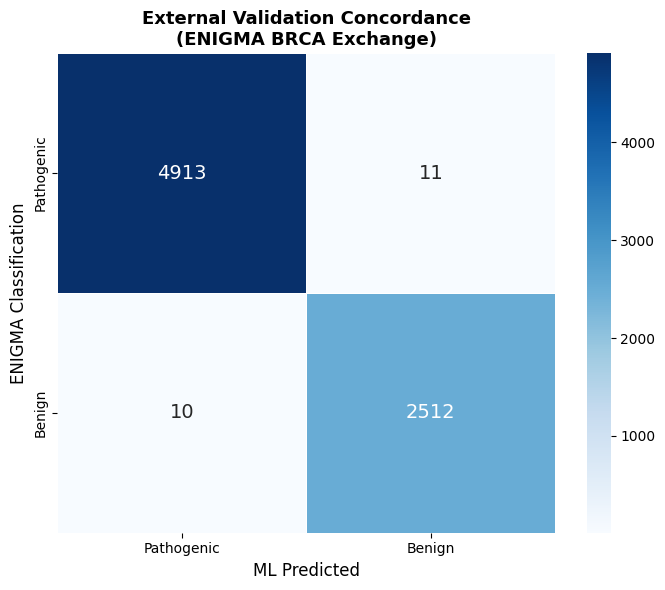

Saved: val_01_concordance_heatmap.png


In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(
    merged['enigma_group'],
    merged['predicted_class'].replace('VUS', 'Benign'),
    labels=['Pathogenic', 'Benign']
)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pathogenic', 'Benign'],
            yticklabels=['Pathogenic', 'Benign'],
            annot_kws={'size': 14}, linewidths=0.5, ax=ax)
ax.set_xlabel('ML Predicted', fontsize=12)
ax.set_ylabel('ENIGMA Classification', fontsize=12)
ax.set_title('External Validation Concordance\n(ENIGMA BRCA Exchange)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('val_01_concordance_heatmap.png', dpi=150)
plt.show()
print('Saved: val_01_concordance_heatmap.png')

### Plot 2: ROC Curve  
`→ saves: val_02_roc_curve.png`

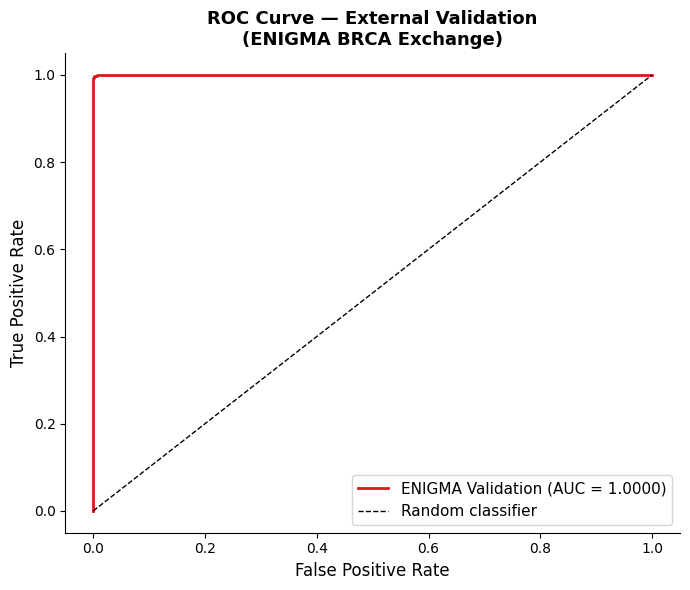

Saved: val_02_roc_curve.png


In [21]:
fpr, tpr, _ = roc_curve(enigma_binary, merged['rf_prob'])

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#D7191C', lw=2,
        label=f'ENIGMA Validation (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — External Validation\n(ENIGMA BRCA Exchange)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('val_02_roc_curve.png', dpi=150)
plt.show()
print('Saved: val_02_roc_curve.png')

### Plot 3: Probability Distribution  
`→ saves: val_03_probability_distribution.png`

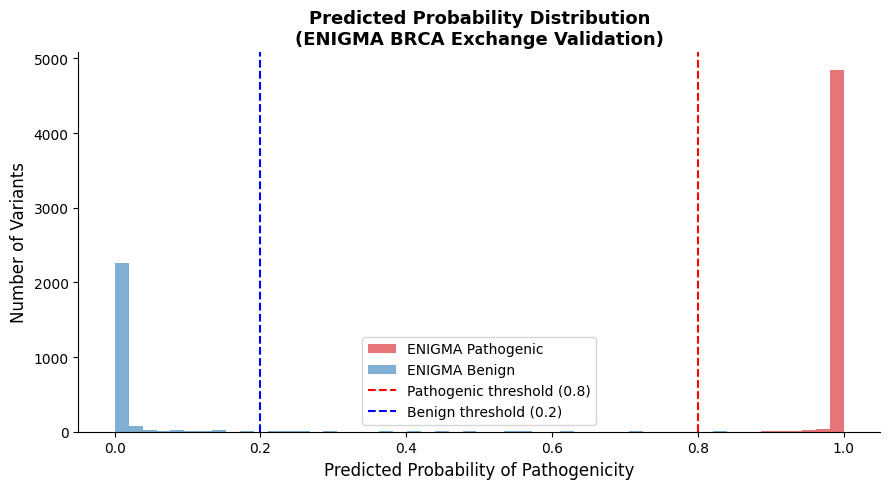

Saved: val_03_probability_distribution.png


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
for group in ['Pathogenic', 'Benign']:
    subset = merged[merged['enigma_group'] == group]['rf_prob']
    ax.hist(subset, bins=50, alpha=0.6, color=COLORS[group],
            label=f'ENIGMA {group}', edgecolor='none')
ax.axvline(x=PATHO_THRESHOLD,  color='red',  linestyle='--', lw=1.5,
           label=f'Pathogenic threshold ({PATHO_THRESHOLD})')
ax.axvline(x=BENIGN_THRESHOLD, color='blue', linestyle='--', lw=1.5,
           label=f'Benign threshold ({BENIGN_THRESHOLD})')
ax.set_xlabel('Predicted Probability of Pathogenicity', fontsize=12)
ax.set_ylabel('Number of Variants', fontsize=12)
ax.set_title('Predicted Probability Distribution\n(ENIGMA BRCA Exchange Validation)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('val_03_probability_distribution.png', dpi=150)
plt.show()
print('Saved: val_03_probability_distribution.png')

### Plot 4: Concordance Bars by ENIGMA Class  
`→ saves: val_04_concordance_bars.png`

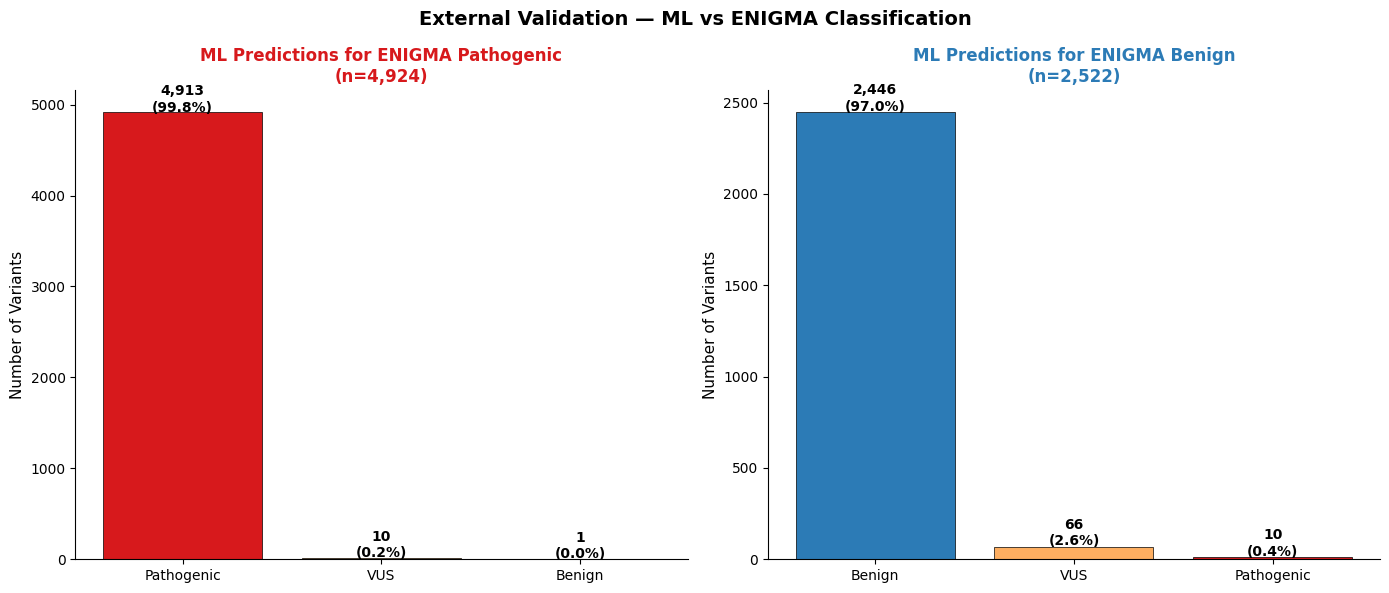

Saved: val_04_concordance_bars.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, group, color in [
    (axes[0], 'Pathogenic', '#D7191C'),
    (axes[1], 'Benign',     '#2C7BB6')
]:
    subset = merged[merged['enigma_group'] == group]
    counts = subset['predicted_class'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=[COLORS.get(c, '#888888') for c in counts.index],
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}\n({val/len(subset)*100:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'ML Predictions for ENIGMA {group}\n(n={len(subset):,})',
                 fontsize=12, fontweight='bold', color=color)
    ax.set_ylabel('Number of Variants', fontsize=11)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('External Validation — ML vs ENIGMA Classification',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('val_04_concordance_bars.png', dpi=150)
plt.show()
print('Saved: val_04_concordance_bars.png')

### Plot 5: Performance Metrics Summary  
`→ saves: val_05_performance_metrics.png`

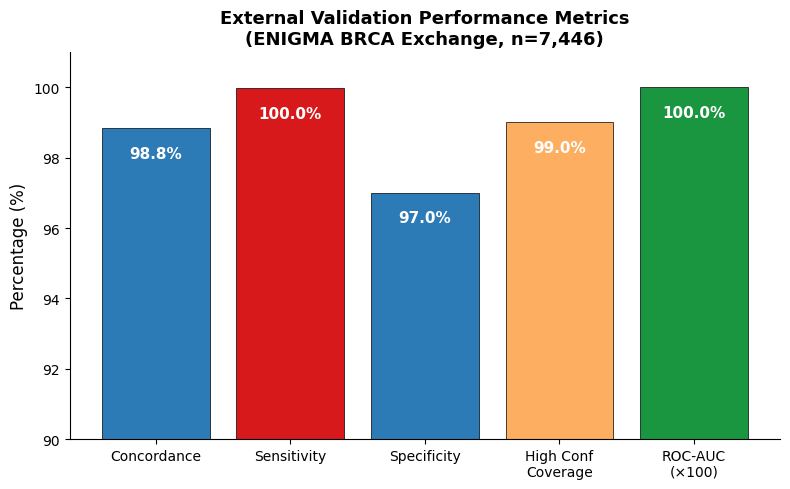

Saved: val_05_performance_metrics.png


In [24]:
# Update these values from the classification_report output above
metrics = {
    'Concordance':       98.83,
    'Sensitivity':       99.98,
    'Specificity':       97.00,
    'High Conf\nCoverage': 99.00,
    'ROC-AUC\n(\u00d7100)':  100.00
}
colors = ['#2C7BB6', '#D7191C', '#2C7BB6', '#FDAE61', '#1A9641']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.5,
            f'{val:.1f}%', ha='center', va='top',
            fontsize=11, fontweight='bold', color='white')
ax.set_ylim(90, 101)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('External Validation Performance Metrics\n(ENIGMA BRCA Exchange, n=7,446)',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('val_05_performance_metrics.png', dpi=150)
plt.show()
print('Saved: val_05_performance_metrics.png')

### Plot 6: VUS Reclassification Concordance  
`→ saves: val_06_vus_concordance.png`

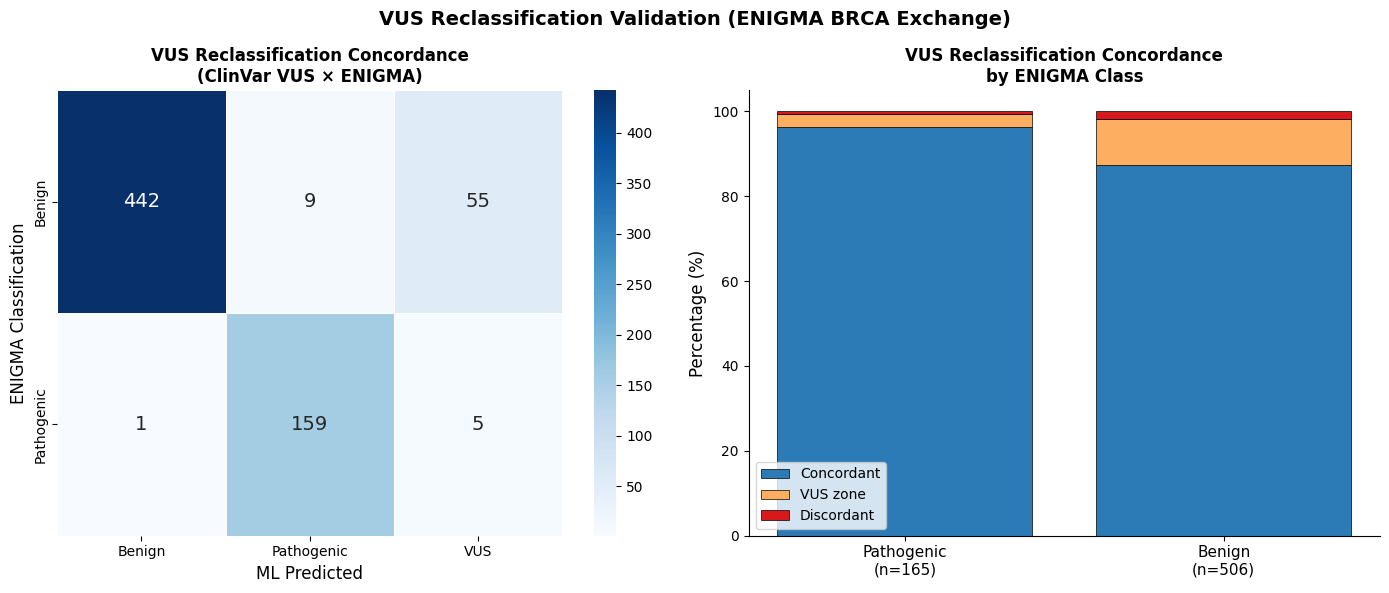

Saved: val_06_vus_concordance.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
cm_vus = pd.crosstab(matched['enigma_group_vus'], matched['predicted_class'])
sns.heatmap(cm_vus, annot=True, fmt='d', cmap='Blues',
            annot_kws={'size': 14}, linewidths=0.5, ax=axes[0])
axes[0].set_xlabel('ML Predicted', fontsize=12)
axes[0].set_ylabel('ENIGMA Classification', fontsize=12)
axes[0].set_title('VUS Reclassification Concordance\n(ClinVar VUS × ENIGMA)',
                  fontsize=12, fontweight='bold')

# Stacked % bars
categories   = [f'Pathogenic\n(n={patho_n})', f'Benign\n(n={benign_n})']
concordant   = [patho_ok/patho_n*100,  benign_ok/benign_n*100]
# VUS-zone and discordant: derive from cross-tab
patho_vus_zone  = matched[(matched['enigma_group_vus']=='Pathogenic') & (matched['predicted_class']=='VUS')].shape[0]
benign_vus_zone = matched[(matched['enigma_group_vus']=='Benign')     & (matched['predicted_class']=='VUS')].shape[0]
vus_zone_pct    = [patho_vus_zone/patho_n*100, benign_vus_zone/benign_n*100]
discordant_pct  = [100 - concordant[0] - vus_zone_pct[0],
                   100 - concordant[1] - vus_zone_pct[1]]

x = range(2)
axes[1].bar(x, concordant,    label='Concordant', color='#2C7BB6', edgecolor='black', linewidth=0.5)
axes[1].bar(x, vus_zone_pct,  bottom=concordant,
            label='VUS zone',  color='#FDAE61', edgecolor='black', linewidth=0.5)
axes[1].bar(x, discordant_pct,
            bottom=[c+v for c,v in zip(concordant, vus_zone_pct)],
            label='Discordant', color='#D7191C', edgecolor='black', linewidth=0.5)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(categories, fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('VUS Reclassification Concordance\nby ENIGMA Class',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('VUS Reclassification Validation (ENIGMA BRCA Exchange)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('val_06_vus_concordance.png', dpi=150)
plt.show()
print('Saved: val_06_vus_concordance.png')

## 8. Export Results

In [26]:
merged.to_csv('enigma_validation_results.tsv', sep='\t', index=False)
matched.to_csv('vus_enigma_concordance.tsv', sep='\t', index=False)

validation_stats = {
    'total_variants':       len(merged),
    'overall_concordance':  float(correct / len(merged) * 100),
    'high_conf_coverage':   float(len(high_conf) / len(merged) * 100),
    'roc_auc':              float(auc),
    'vus_matched':          len(matched),
    'vus_concordance':      float(correct_vus / len(matched) * 100),
    'vus_patho_concordance': float(patho_ok / patho_n * 100),
    'vus_benign_concordance': float(benign_ok / benign_n * 100)
}

with open('enigma_validation_stats.json', 'w') as f:
    json.dump(validation_stats, f, indent=2)

print('Saved:')
print('  enigma_validation_results.tsv')
print('  vus_enigma_concordance.tsv')
print('  enigma_validation_stats.json')
print(f'\nFinal validation stats:')
for k, v in validation_stats.items():
    print(f'  {k}: {v}')

Saved:
  enigma_validation_results.tsv
  vus_enigma_concordance.tsv
  enigma_validation_stats.json

Final validation stats:
  total_variants: 7446
  overall_concordance: 98.83158742949234
  high_conf_coverage: 98.97931775449906
  roc_auc: 0.9999585290386918
  vus_matched: 671
  vus_concordance: 89.56780923994039
  vus_patho_concordance: 96.36363636363636
  vus_benign_concordance: 87.35177865612648
